# Pareto Distribution

This module will present how Pareto distribution is visualized in the context of Resource Foraging.
$P(l)$ is the probability of making a jump of length $l$.
The vertical axis shows the probability density function (PDF) value for each jump length.
Where the horizontal axis shows the jump length $l$ and labels it using a logarithmic scale form.
Give labels to the axes and a title to the plot.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

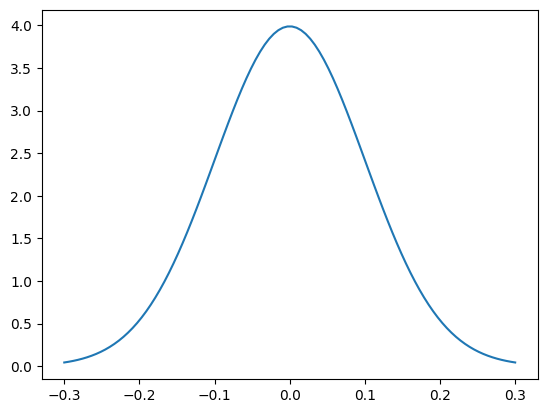

In [5]:
# Visualizing normal (gaussian) distribution

mu = 0
sigma = 0.1
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, np.exp(-(x-mu)**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi)))
plt.show()

# Formulas used

The Pareto distribution with probability density function (PDF) $P(l)$ is defined as:

$f(x;\mu;x_0) = (\mu − 1) \cdot {x_0}^{μ−1 } \cdot (\frac{1}{x})^\mu, x \geq x_0$

Where:
- $x_0$ is the minimum value of the step length.
- $\mu$ is the Lévy Flight exponent, the shape parameter which controls the tail heaviness.
- $x$ is the step length being evaluated.


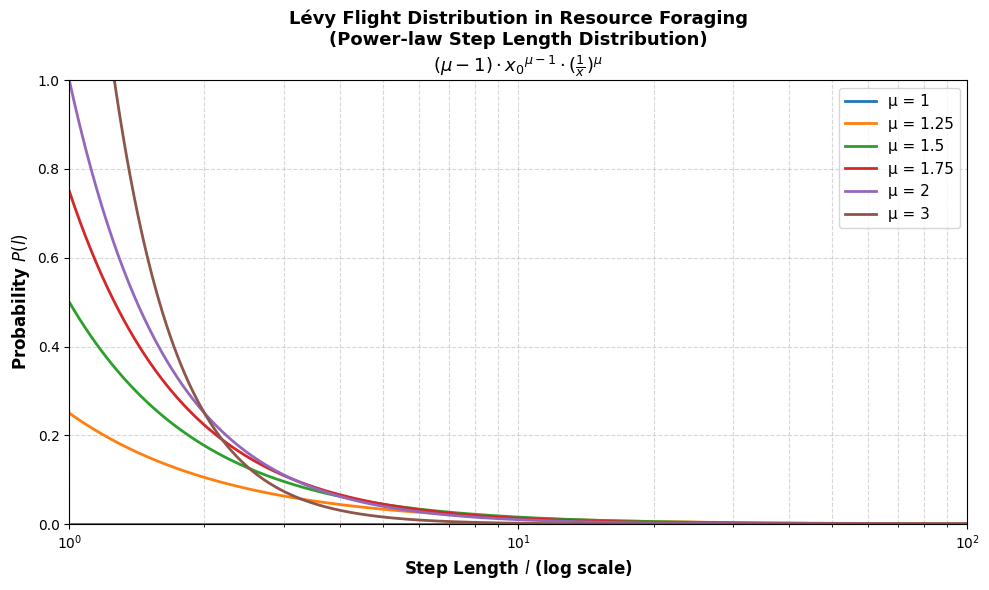

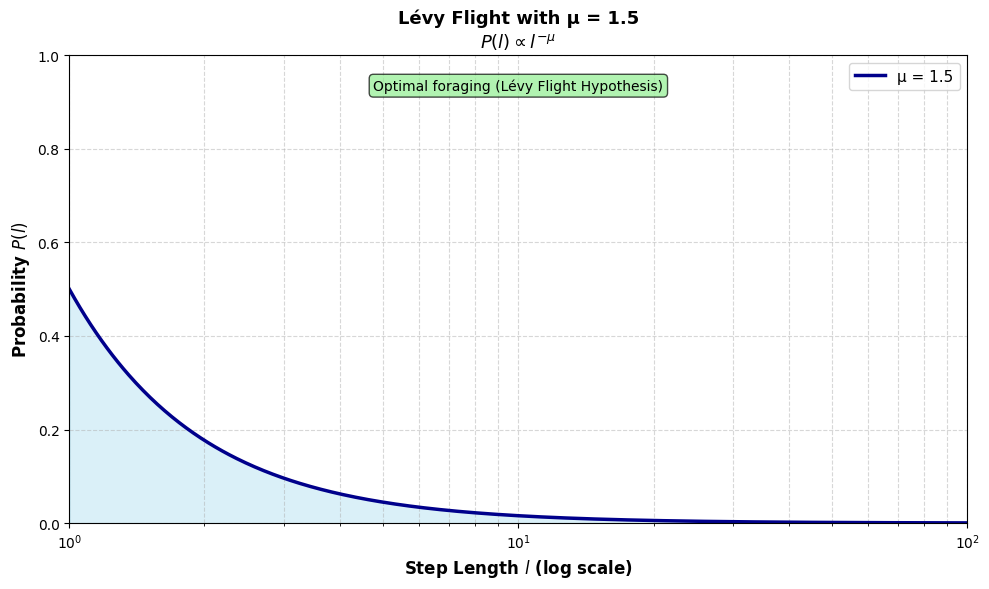

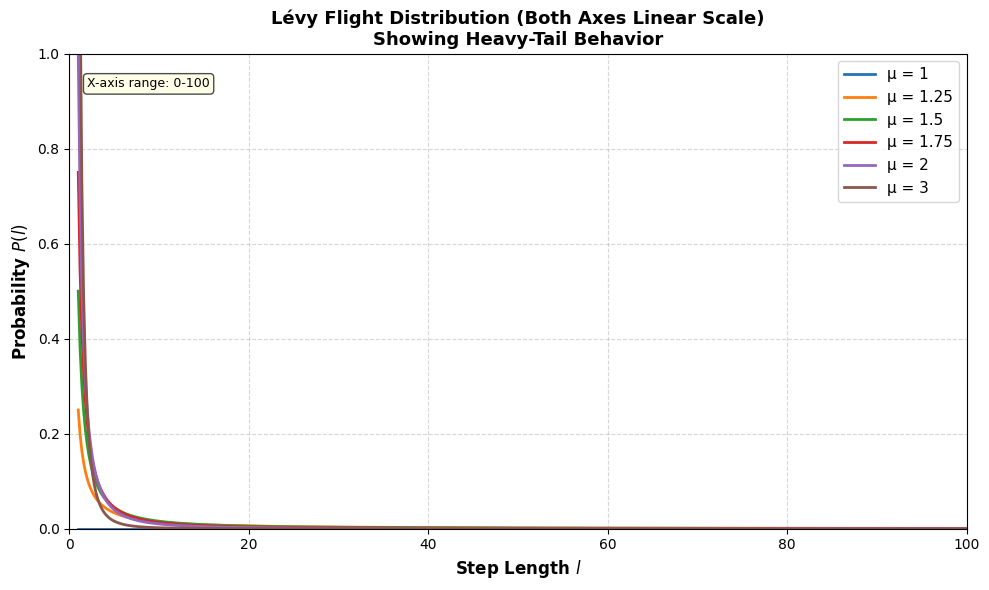

Lévy Flight / Pareto Distribution Parameters
μ (mu): Controls the tail heaviness
  - μ < 2  : Superdiffusive (more long jumps → exploration)
  - μ = 2  : Optimal Lévy Flight (balanced)
  - μ > 2  : Approaching Brownian Motion (exploitation)

Formula: P(l) ∝ l^(-μ)
Current μ value in Figure 2: 1.5
L_max parameter: 100

Figure Descriptions:
  - Figure 1: Multiple μ comparison (log X, linear Y)
  - Figure 2: Single μ detailed view (log X, linear Y)
  - Figure 3: Linear scale (linear X, linear Y)


In [6]:
# Lévy Flight / Pareto Distribution Visualization for Resource Foraging

# Parameters
# mu_values = [1, 1.5, 2, 2.5, 3]  # Different mu values to compare
mu_values = [1, 1.25, 1.5, 1.75, 2, 3]  # Different mu values to compare
# mu_values = [1, 1.25, 1.5, 1.75, 2, 2.5, 3]  # Different mu values to compare
# mu_values = [1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2]  # Different mu values to compare
L_min = 1  # Minimum jump length
L_max = 100  # Maximum jump length

# Generate jump lengths (logarithmically spaced for better visualization)
L = np.logspace(0, np.log10(L_max), 500)

# --- FIGURE 1: Multiple mu values comparison (LOG X, LINEAR Y) ---
fig1, ax1 = plt.subplots(figsize=(10, 6))

for mu in mu_values:
    # Lévy Flight probability: P(L) ∝ L^(-mu)
    # Normalized Pareto distribution
    P_L = (mu - 1) * (L_min**(mu - 1)) * (1 / L)**mu

    ax1.semilogx(L, P_L, linewidth=2, label=f'μ = {mu}')

ax1.set_xlabel('Step Length $l$ (log scale)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability Density $P(l)$', fontsize=12, fontweight='bold')
ax1.set_title('Lévy Flight Distribution in Resource Foraging\n'
              '(Power-law Step Length Distribution)\n'
              '$(\\mu − 1) \\cdot {{x_0}}^{{\\mu−1}} \\cdot (\\frac{{1}}{{x}})^\\mu$',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.5, which='both', linestyle='--')
ax1.set_xlim(L_min, L_max)
ax1.set_ylim(0, 1.0)

# Add annotation
# ax1.text(0.05, 0.95, 'Heavy-tailed distribution:\nFrequent short jumps,\noccasional long jumps',
#          transform=ax1.transAxes, fontsize=10, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# --- FIGURE 2: Interactive single mu visualization (LOG X, LINEAR Y) ---
mu_interactive = 1.5  # Change this value to see different distributions

fig2, ax2 = plt.subplots(figsize=(10, 6))

P_L_interactive = P_L = (mu_interactive - 1) * (L_min**(mu_interactive - 1)) * (1 / L)**mu_interactive

ax2.semilogx(L, P_L_interactive, linewidth=2.5, color='darkblue', label=f'μ = {mu_interactive}')
ax2.fill_between(L, P_L_interactive, alpha=0.3, color='skyblue')

ax2.set_xlabel('Step Length $l$ (log scale)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density $P(l)$', fontsize=12, fontweight='bold')
ax2.set_title(f'Lévy Flight with μ = {mu_interactive}\n$P(l) \\propto l^{{-\\mu}}$',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.5, which='both', linestyle='--')
ax2.set_xlim(L_min, L_max)
ax2.set_ylim(0, 1.0)

# Add behavioral interpretation
if mu_interactive < 1:
    behavior = "Superdiffusive: More exploration"
elif mu_interactive <= 2:
    behavior = "Optimal foraging (Lévy Flight Hypothesis)"
else:
    behavior = "Approaching Brownian: More exploitation"

ax2.text(0.5, 0.95, behavior, transform=ax2.transAxes, fontsize=10,
         horizontalalignment='center', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

# --- FIGURE 3: Both axes LINEAR scale comparison ---
fig3, ax3 = plt.subplots(figsize=(10, 6))

# IMPORTANT: Use linear spacing for linear X-axis
L_linear = np.linspace(1, L_max, 500)  # Changed to use L_max instead of hardcoded 100

for mu in mu_values:
    P_L_linear = (mu - 1) * (L_min**(mu - 1)) * (1 / L_linear)**mu
    ax3.plot(L_linear, P_L_linear, linewidth=2, label=f'μ = {mu}')

ax3.set_xlabel('Step Length $l$', fontsize=12, fontweight='bold')
ax3.set_ylabel('Probability Density $P(l)$', fontsize=12, fontweight='bold')
ax3.set_title('Lévy Flight Distribution (Both Axes Linear Scale)\nShowing Heavy-Tail Behavior',
              fontsize=13, fontweight='bold')
ax3.legend(fontsize=11, loc='upper right')
ax3.grid(True, alpha=0.5, linestyle='--')
ax3.set_xlim(0, L_max)  # Changed to L_max
ax3.set_ylim(0, 1.0)

# Add note about scale
ax3.text(0.02, 0.95, f'X-axis range: 0-{L_max}',
         transform=ax3.transAxes, fontsize=9,
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("=" * 60)
print("Lévy Flight / Pareto Distribution Parameters")
print("=" * 60)
print(f"μ (mu): Controls the tail heaviness")
print(f"  - μ < 2  : Superdiffusive (more long jumps → exploration)")
print(f"  - μ = 2  : Optimal Lévy Flight (balanced)")
print(f"  - μ > 2  : Approaching Brownian Motion (exploitation)")
print(f"\nFormula: P(l) ∝ l^(-μ)")
print(f"Current μ value in Figure 2: {mu_interactive}")
print(f"L_max parameter: {L_max}")
print("=" * 60)
print("\nFigure Descriptions:")
print("  - Figure 1: Multiple μ comparison (log X, linear Y)")
print("  - Figure 2: Single μ detailed view (log X, linear Y)")
print("  - Figure 3: Linear scale (linear X, linear Y)")
print("=" * 60)
